In [1]:
import pandas as pd

# 读取刚才上传的 csv 文件
df = pd.read_csv('ecommerce_data.csv')

# 查看前 5 行数据，确认读取成功
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# 查看数据的维度 (行数, 列数)
print("数据集的行数和列数：", df.shape)

数据集的行数和列数： (12462, 8)


In [3]:
# 查看每一列的数据类型和非空数量
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12462 entries, 0 to 12461
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    12462 non-null  str    
 1   StockCode    12462 non-null  str    
 2   Description  12417 non-null  str    
 3   Quantity     12461 non-null  float64
 4   InvoiceDate  12461 non-null  str    
 5   UnitPrice    12461 non-null  float64
 6   CustomerID   8956 non-null   float64
 7   Country      12461 non-null  str    
dtypes: float64(3), str(5)
memory usage: 779.0 KB


In [4]:
# 统计每一列的缺失值数量
print(df.isnull().sum())

InvoiceNo         0
StockCode         0
Description      45
Quantity          1
InvoiceDate       1
UnitPrice         1
CustomerID     3506
Country           1
dtype: int64


In [5]:
# 查看时间的最小值和最大值
print("最早时间:", df['InvoiceDate'].min())
print("最晚时间:", df['InvoiceDate'].max())

最早时间: 12/1/2010 10:03
最晚时间: 12/6/2010 9:58


In [6]:
# --- 开始数据清洗 ---

# 1. 统一日期格式 (非常重要，否则后面没法按时间分析)
# 将 InvoiceDate 从字符串转换为 datetime 对象
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. 处理缺失值
# 策略：删除 CustomerID 为空的行 (因为我们要分析客户行为)
df_clean = df.dropna(subset=['CustomerID'])

# 策略：删除其他列有缺失的行 (Description, Quantity 等)
# inplace=False 表示不修改原数据，而是生成新的 df_clean，这里我们链式操作
df_clean = df_clean.dropna()

# 3. 数据类型转换
# 把 CustomerID 从浮点数 (12345.0) 转为整数 (12345)，看起来更舒服
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 4. 去除重复值
# 防止系统故障导致同一笔订单被记录了两次
df_clean = df_clean.drop_duplicates()

# --- 清洗完成，查看结果 ---
print("清洗前行数:", len(df))
print("清洗后行数:", len(df_clean))
print("丢失行数:", len(df) - len(df_clean))

# 再次确认一下数据类型，看看 InvoiceDate 变没变
df_clean.info()

清洗前行数: 12462
清洗后行数: 8720
丢失行数: 3742
<class 'pandas.DataFrame'>
Index: 8720 entries, 0 to 12460
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    8720 non-null   str           
 1   StockCode    8720 non-null   str           
 2   Description  8720 non-null   str           
 3   Quantity     8720 non-null   float64       
 4   InvoiceDate  8720 non-null   datetime64[us]
 5   UnitPrice    8720 non-null   float64       
 6   CustomerID   8720 non-null   int64         
 7   Country      8720 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 613.1 KB


In [7]:
# 1. 新增一列：交易总金额 (数量 * 单价)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 2. 按商品描述分组，统计销量和销售额
product_sales = df_clean.groupby('Description').agg(
    Total_Quantity=('Quantity', 'sum'),    # 总销量
    Total_Revenue=('TotalPrice', 'sum')    # 总销售额
).reset_index()

# 3. 按销售额降序排列，查看前10名
print("=== 💰 Top 10 最赚钱的商品 ===")
print(product_sales.sort_values(by='Total_Revenue', ascending=False).head(10))

=== 💰 Top 10 最赚钱的商品 ===
                             Description  Total_Quantity  Total_Revenue
1306            REGENCY CAKESTAND 3 TIER           476.0        5363.40
197             BLACK RECORD COVER FRAME          1141.0        3868.35
1734  WHITE HANGING HEART T-LIGHT HOLDER          1014.0        2665.70
376                        CHILLI LIGHTS           572.0        2379.24
1305      RED WOOLLY HOTTIE WHITE HEART.           726.0        2275.14
1399        SET 7 BABUSHKA NESTING BOXES           255.0        1989.00
1243              RED  HARMONICA IN BOX           1677.0        1830.25
269       BOX OF VINTAGE ALPHABET BLOCKS           180.0        1564.80
761        HAND WARMER SCOTTY DOG DESIGN           741.0        1508.10
119        ASSORTED COLOUR BIRD ORNAMENT           920.0        1478.00



=== 👑 Top 10 消费最高的客户 (大金主) ===
     CustomerID  Frequency  Monetary
156       15061         73   9407.34
78        13777         33   6585.16
334       17850        297   5391.21
236       16210         25   4738.54
224       16029         12   4271.52
302       17381         11   3603.72
149       14911        128   3445.18
43        13081         74   2366.78
263       16754          2   2002.40
3         12433         73   1919.14


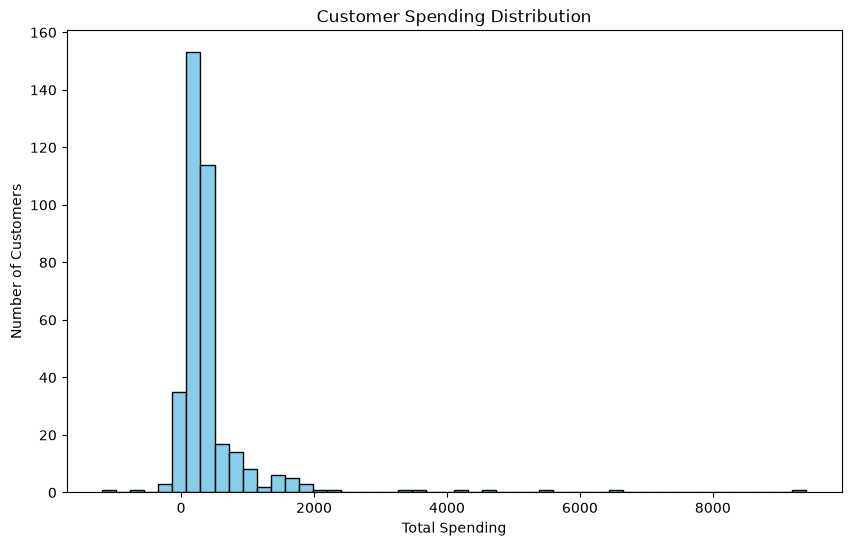

In [8]:
# 1. 按客户ID分组统计
customer_stats = df_clean.groupby('CustomerID').agg(
    Frequency=('InvoiceNo', 'count'),      # 购买次数 (F)
    Monetary=('TotalPrice', 'sum')         # 消费总额 (M)
).reset_index()

# 2. 查看消费金额最高的 Top 10 客户
print("\n=== 👑 Top 10 消费最高的客户 (大金主) ===")
top_customers = customer_stats.sort_values(by='Monetary', ascending=False).head(10)
print(top_customers)

# 可选：简单画个图看看分布（如果没装matplotlib可以跳过画图部分）
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(customer_stats['Monetary'], bins=50, color='skyblue', edgecolor='black')
plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()


=== ⏰ 各时间段订单量分布 ===
    Hour  Order_Count
0      7           10
1      8          129
2      9          325
3     10          717
4     11         1346
5     12         2106
6     13         1164
7     14          873
8     15          960
9     16          601
10    17          267
11    18          123
12    19           99


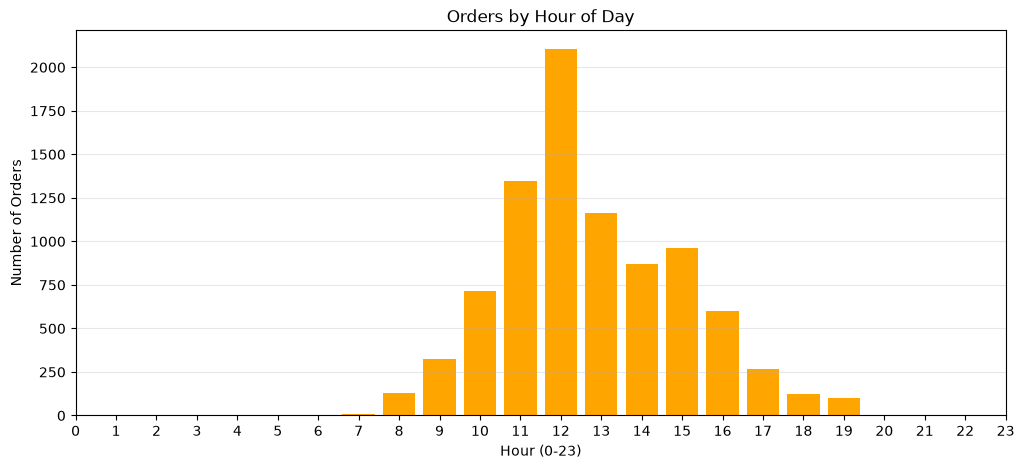

In [9]:
# 1. 提取“小时”字段
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 2. 按小时统计订单量
hourly_sales = df_clean.groupby('Hour')['InvoiceNo'].count().reset_index()
hourly_sales.columns = ['Hour', 'Order_Count']

# 3. 排序并打印
hourly_sales = hourly_sales.sort_values(by='Hour')
print("\n=== ⏰ 各时间段订单量分布 ===")
print(hourly_sales)

# 画图：每小时订单量趋势
plt.figure(figsize=(12, 5))
plt.bar(hourly_sales['Hour'], hourly_sales['Order_Count'], color='orange')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
# 1. 核心步骤：计算每一笔交易的总金额
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 2. 按商品名称分组，统计销量和销售额
product_analysis = df_clean.groupby('Description').agg(
    Total_Quantity=('Quantity', 'sum'),    # 总销量
    Total_Revenue=('TotalPrice', 'sum')    # 总销售额
).reset_index()

# 3. 查看最赚钱的 Top 10 商品
print("=== 💰 Top 10 最赚钱的商品 ===")
top_products = product_analysis.sort_values(by='Total_Revenue', ascending=False).head(10)
print(top_products)

=== 💰 Top 10 最赚钱的商品 ===
                             Description  Total_Quantity  Total_Revenue
1306            REGENCY CAKESTAND 3 TIER           476.0        5363.40
197             BLACK RECORD COVER FRAME          1141.0        3868.35
1734  WHITE HANGING HEART T-LIGHT HOLDER          1014.0        2665.70
376                        CHILLI LIGHTS           572.0        2379.24
1305      RED WOOLLY HOTTIE WHITE HEART.           726.0        2275.14
1399        SET 7 BABUSHKA NESTING BOXES           255.0        1989.00
1243              RED  HARMONICA IN BOX           1677.0        1830.25
269       BOX OF VINTAGE ALPHABET BLOCKS           180.0        1564.80
761        HAND WARMER SCOTTY DOG DESIGN           741.0        1508.10
119        ASSORTED COLOUR BIRD ORNAMENT           920.0        1478.00


In [11]:
# 1. 按客户ID分组，统计购买频次(F)和消费总额(M)
customer_analysis = df_clean.groupby('CustomerID').agg(
    Frequency=('InvoiceNo', 'nunique'), # 购买了几次 (去重订单号)
    Monetary=('TotalPrice', 'sum')      # 总共花了多少钱
).reset_index()

# 2. 查看消费金额最高的 Top 10 客户
print("\n=== 👑 Top 10 消费最高的客户 (大金主) ===")
top_customers = customer_analysis.sort_values(by='Monetary', ascending=False).head(10)
print(top_customers)


=== 👑 Top 10 消费最高的客户 (大金主) ===
     CustomerID  Frequency  Monetary
156       15061          6   9407.34
78        13777          7   6585.16
334       17850         34   5391.21
236       16210          2   4738.54
224       16029          3   4271.52
302       17381          3   3603.72
149       14911          6   3445.18
43        13081          2   2366.78
263       16754          1   2002.40
3         12433          1   1919.14


In [12]:
# 1. 提取“小时”列
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 2. 按小时统计订单量
hourly_trend = df_clean.groupby('Hour')['InvoiceNo'].count().reset_index()
hourly_trend.columns = ['Hour', 'Order_Count']

# 3. 按时间排序查看
print("\n=== ⏰ 24小时下单热度分布 ===")
print(hourly_trend.sort_values(by='Hour'))


=== ⏰ 24小时下单热度分布 ===
    Hour  Order_Count
0      7           10
1      8          129
2      9          325
3     10          717
4     11         1346
5     12         2106
6     13         1164
7     14          873
8     15          960
9     16          601
10    17          267
11    18          123
12    19           99


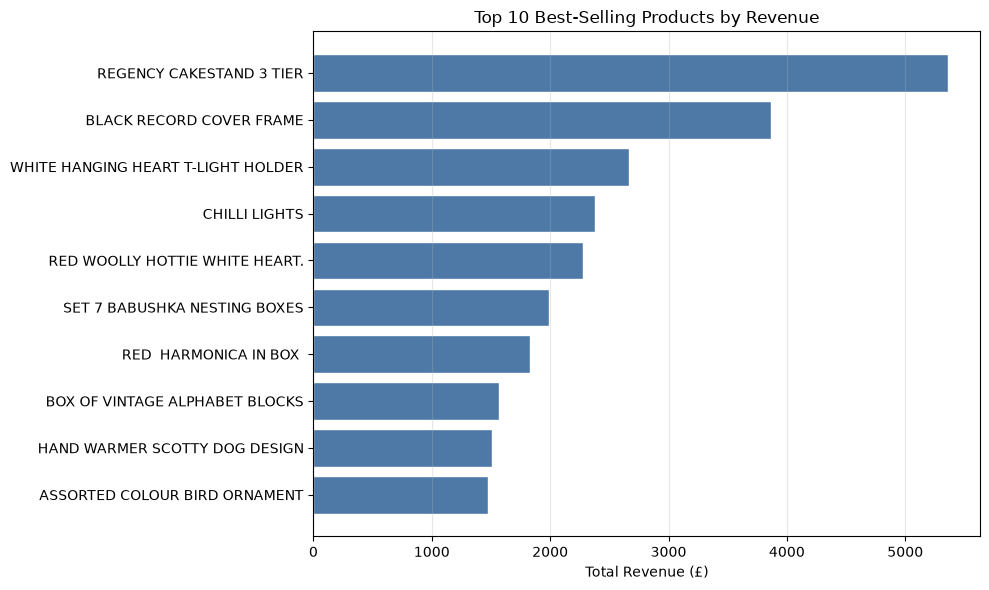

In [13]:
import matplotlib.pyplot as plt

# 按销售额降序取Top 10
top10 = product_analysis.sort_values(by='Total_Revenue', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Description'], top10['Total_Revenue'], color='#4E79A7', edgecolor='white')
plt.xlabel('Total Revenue (£)')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

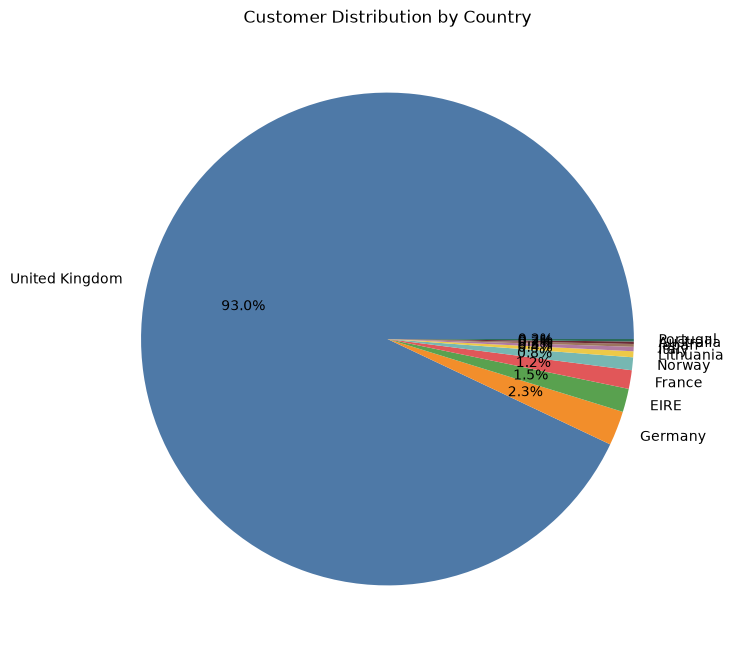

In [15]:
country_stats = df_clean.groupby('Country').size().reset_index(name='Count')
country_stats = country_stats.sort_values(by='Count', ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(country_stats['Count'], labels=country_stats['Country'], autopct='%1.1f%%',
        colors=['#4E79A7','#F28E2B','#59A14F','#E15759','#76B7B2','#EDC948','#B07AA1','#9C755F','#6B2A35','#2A6B5A'])
plt.title('Customer Distribution by Country')
plt.show()

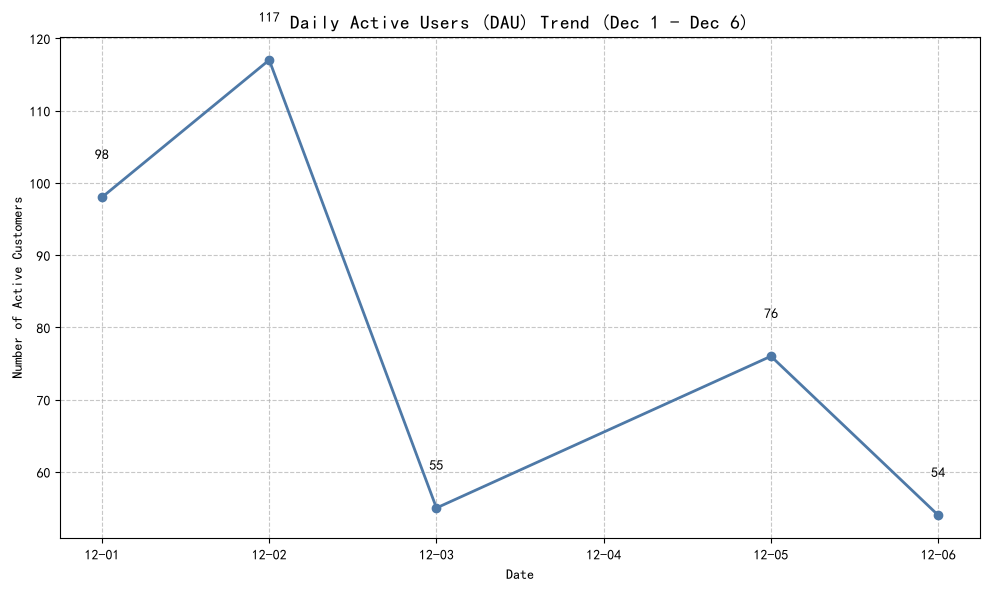

结论：观察折线图，可以看出哪一天的客流量最高，哪一天出现了下滑。


In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文显示（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 按日期统计每天的独立客户数 (DAU)
daily_active_users = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['CustomerID'].nunique()

# 2. 绘图：DAU 趋势折线图
plt.figure(figsize=(10, 6))
plt.plot(daily_active_users.index, daily_active_users.values, marker='o', linestyle='-', color='#4E79A7', linewidth=2)

plt.title('Daily Active Users (DAU) Trend (Dec 1 - Dec 6)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Active Customers')
plt.grid(True, linestyle='--', alpha=0.7)

# 格式化X轴日期
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# 添加数据标签
for x, y in zip(daily_active_users.index, daily_active_users.values):
    plt.text(x, y + 5, str(y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("结论：观察折线图，可以看出哪一天的客流量最高，哪一天出现了下滑。")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19836\824565295.py:18: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from font(s) SimHei.
  plt.tight_layout()


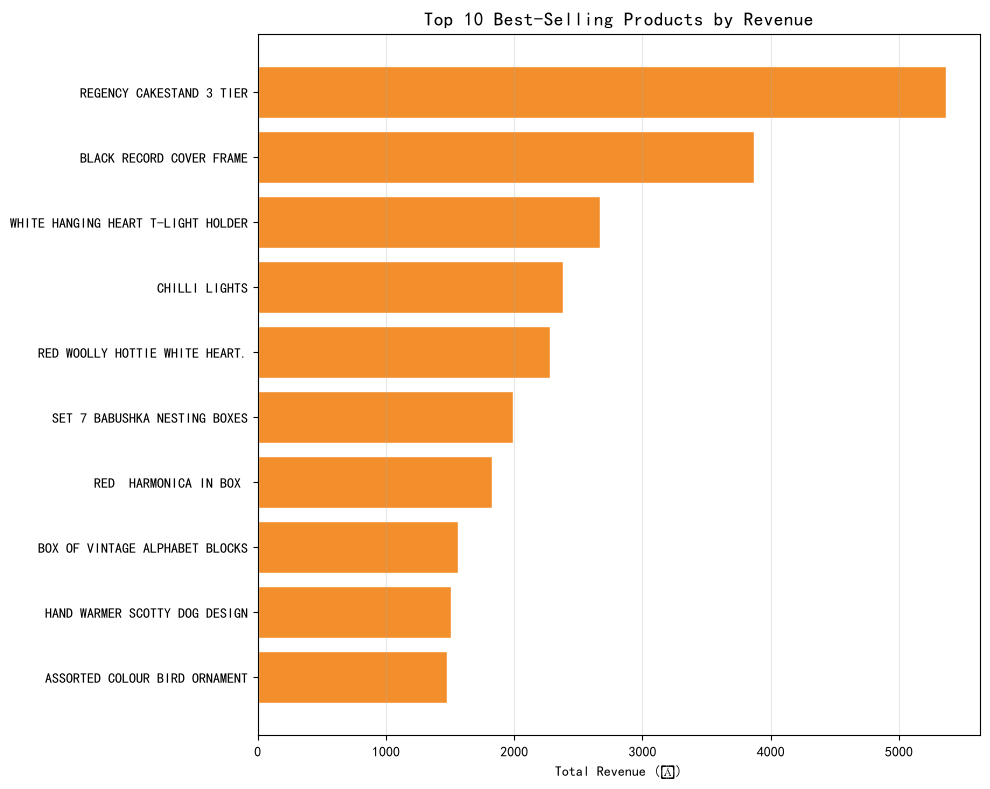

结论：销售额最高的商品是 'REGENCY CAKESTAND 3 TIER'，贡献了 £5363.40。


In [18]:
# 1. 确保有 TotalPrice 列（如果没有请先运行：df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']）

# 2. 按商品描述分组，计算总销售额
top_products = df_clean.groupby('Description')['TotalPrice'].sum().reset_index()

# 3. 排序并取前 10 名
top_10_products = top_products.sort_values(by='TotalPrice', ascending=False).head(10)

# 4. 绘图：横向柱状图
plt.figure(figsize=(10, 8))
plt.barh(top_10_products['Description'], top_10_products['TotalPrice'], color='#F28E2B', edgecolor='white')

plt.title('Top 10 Best-Selling Products by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.gca().invert_yaxis() # 让第一名显示在最上面
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"结论：销售额最高的商品是 '{top_10_products.iloc[0]['Description']}'，贡献了 £{top_10_products.iloc[0]['TotalPrice']:.2f}。")

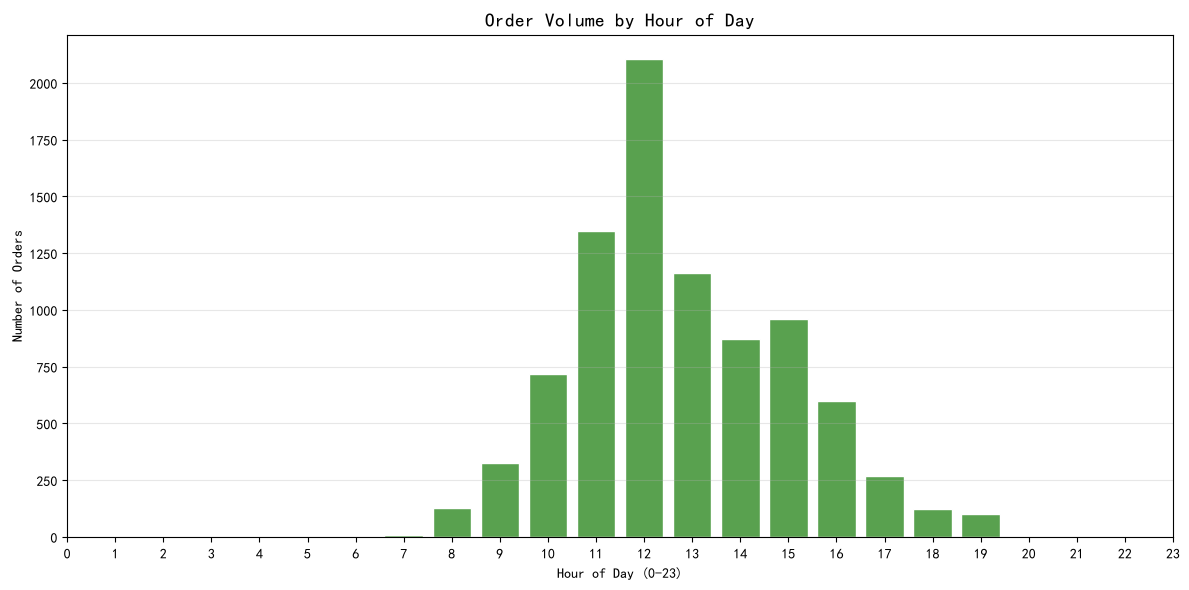

结论：观察波峰，找出下单最集中的时间段（例如上午10点或下午3点）。


In [19]:
# 1. 提取“小时”列
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 2. 统计每小时的订单量
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].count()

# 3. 绘图：柱状图
plt.figure(figsize=(12, 6))
plt.bar(hourly_orders.index, hourly_orders.values, color='#59A14F', edgecolor='white')

plt.title('Order Volume by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24)) # 确保显示所有小时
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("结论：观察波峰，找出下单最集中的时间段（例如上午10点或下午3点）。")

=== 复购率分析报告 ===
总客户数: 371
复购客户数 (购买>=2次): 66
短期复购率: 17.79%


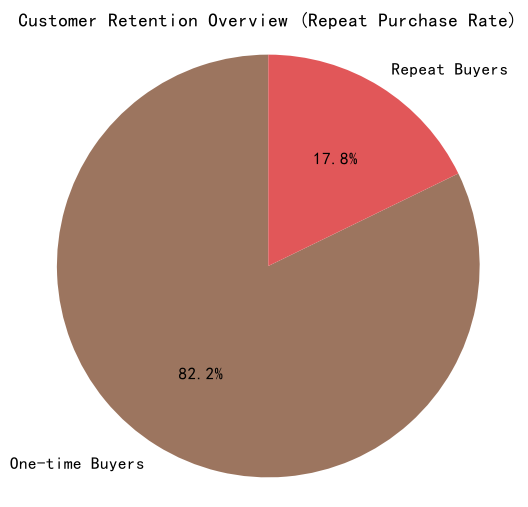

In [20]:
# 1. 统计每个客户的购买次数
customer_freq = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()

# 2. 计算复购人数（购买次数 >= 2 的客户）
repeat_customers = (customer_freq >= 2).sum()
total_customers = len(customer_freq)

# 3. 计算复购率
retention_rate = (repeat_customers / total_customers) * 100

print(f"=== 复购率分析报告 ===")
print(f"总客户数: {total_customers}")
print(f"复购客户数 (购买>=2次): {repeat_customers}")
print(f"短期复购率: {retention_rate:.2f}%")

# 4. 绘图：复购 vs 单次购买 饼图
labels = ['One-time Buyers', 'Repeat Buyers']
sizes = [total_customers - repeat_customers, repeat_customers]
colors = ['#9C755F', '#E15759']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title('Customer Retention Overview (Repeat Purchase Rate)', fontsize=14)
plt.axis('equal') 
plt.show()

In [24]:
# === 🛠️ 万能修复版 RFM 打分代码 ===

# 1. R 打分 (Recency) - 天数越少越好
# 使用 rank(pct=True) 将数据转化为百分比排名 (0~1)，这样无论怎么分都不会报错
# ascending=False 表示数值越小（越近），排名越靠前（分数越高）
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=False, duplicates='drop')
# 因为我们要“越小越好”，所以反转分数：如果是5分制，用 4减去当前分 (0->4, 4->0)
# 这里简单处理：直接取反逻辑，或者保留 0-4 分制也可以。
# 为了符合业务习惯（5分最高），我们手动映射一下：
r_scores = rfm['R_Score'].value_counts().sort_index().index.tolist() 
# 这一步比较绕，我们用最简单的逻辑：
# qcut labels=False 会生成 0,1,2,3,4。
# 对于 R，0代表天数最少（最好），4代表天数最多（最差）。
# 我们需要把它变成：4,3,2,1,0 或者 5,4,3,2,1。
rfm['R_Score'] = 4 - rfm['R_Score'] # 现在 4分最好，0分最差

# 2. F 打分 (Frequency) - 次数越多越好
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=False, duplicates='drop')
# F 不需要反转，生成的 4 就是最大的，最好的。

# 3. M 打分 (Monetary) - 金额越大越好
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=False, duplicates='drop')
# M 也不需要反转。

# === 检查打分结果 ===
print("=== ✅ 打分完成 (0-4分制) ===")
print(rfm[['Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score']].head(10))

# === 可选：如果你想强行变成 1-5 分制 ===
rfm['R_Score'] = rfm['R_Score'] + 1
rfm['F_Score'] = rfm['F_Score'] + 1
rfm['M_Score'] = rfm['M_Score'] + 1

print("\n=== 转换为 1-5 分制后 ===")
print(rfm.head())

=== ✅ 打分完成 (0-4分制) ===
            Recency  R_Score  Frequency  F_Score  Monetary  M_Score
CustomerID                                                         
12395             3        3          1        0    346.10        3
12427             4        2          1        0    303.50        2
12431             6        0          1        0    358.25        3
12433             5        1          1        0   1919.14        4
12471             5        1          1        0    -17.00        0
12472             1        4          2        4   1509.00        4
12474             1        4          1        0    -34.00        0
12557             4        2          1        0    620.00        4
12567             2        3          1        0   1526.92        4
12583             6        0          1        0    855.86        4

=== 转换为 1-5 分制后 ===
            Recency  Frequency  Monetary  R_Score  F_Score  M_Score
CustomerID                                                         
1239

In [25]:
# === 步骤 2：RFM 用户分层 ===

# 1. 计算 R, F, M 得分的平均值作为分割线
r_mean = rfm['R_Score'].mean()
f_mean = rfm['F_Score'].mean()
m_mean = rfm['M_Score'].mean()

# 2. 定义打标函数
def label_customer(row):
    # 判断 R (注意：R分数越高越好，代表天数越少)
    if row['R_Score'] >= r_mean:
        r_label = '高'
    else:
        r_label = '低'
        
    # 判断 F
    if row['F_Score'] >= f_mean:
        f_label = '高'
    else:
        f_label = '低'
        
    # 判断 M
    if row['M_Score'] >= m_mean:
        m_label = '高'
    else:
        m_label = '低'
    
    # 3. 组合标签 (这里列举最常见的几种核心人群)
    if r_label == '高' and f_label == '高' and m_label == '高':
        return '重要价值客户'
    elif r_label == '低' and f_label == '高' and m_label == '高':
        return '重要保持客户' # 也就是流失风险客户
    elif r_label == '高' and f_label == '低' and m_label == '低':
        return '重要发展客户' # 新客户潜力股
    elif r_label == '低' and f_label == '低' and m_label == '低':
        return '一般挽留客户'
    elif r_label == '高' and f_label == '高' and m_label == '低':
        return '一般价值客户'
    else:
        return '其他客户'

# 4. 应用函数
rfm['Customer_Level'] = rfm.apply(label_customer, axis=1)

# 预览一下结果
print("=== 各层级人数统计 ===")
print(rfm['Customer_Level'].value_counts())

=== 各层级人数统计 ===
Customer_Level
其他客户      134
重要保持客户     77
重要价值客户     60
一般挽留客户     43
一般价值客户     36
重要发展客户     21
Name: count, dtype: int64


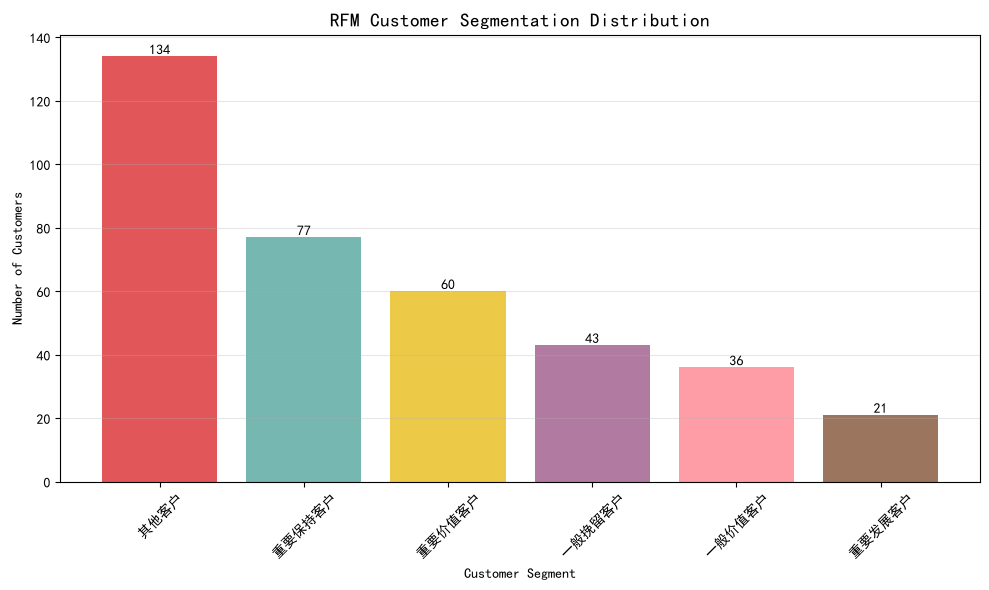

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# 统计各层级人数并排序
level_counts = rfm['Customer_Level'].value_counts()

# 绘制柱状图
bars = plt.bar(level_counts.index, level_counts.values, color=['#E15759', '#76B7B2', '#EDC948', '#B07AA1', '#FF9DA7', '#9C755F'])

plt.title('RFM Customer Segmentation Distribution', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# 在柱子上方显示具体数字
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

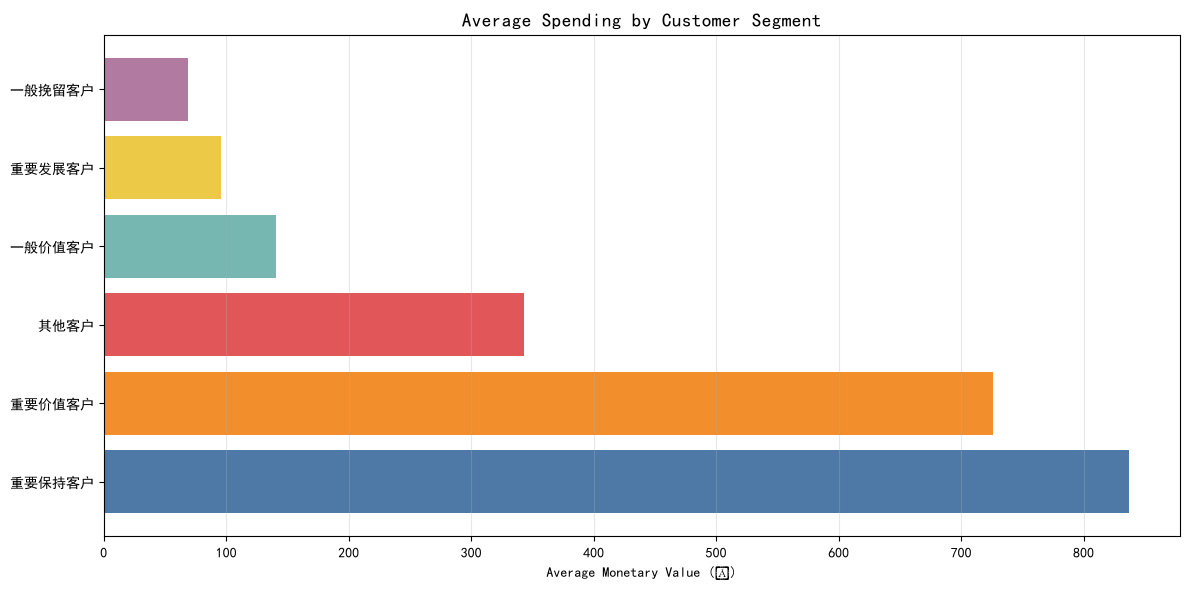

In [28]:
# 方法一：简单粗暴，把字体改成支持英文的 Arial (但这会导致中文变乱码)
# plt.rcParams['font.sans-serif'] = ['Arial'] 

# 方法二（推荐）：保留中文，但手动指定一个包含英镑符号的字体，或者忽略警告
import warnings
warnings.filterwarnings('ignore') # 眼不见为净，直接屏蔽警告
plt.figure(figsize=(12, 6))

# 计算各层级的平均 Monetry (消费金额)
avg_monetary_by_level = rfm.groupby('Customer_Level')['Monetary'].mean().sort_values(ascending=False)

# 绘制横向柱状图
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#EDC948', '#B07AA1']
plt.barh(avg_monetary_by_level.index, avg_monetary_by_level.values, color=colors[:len(avg_monetary_by_level)])

plt.title('Average Spending by Customer Segment', fontsize=14)
plt.xlabel('Average Monetary Value (£)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# 1. 统计每个客户的购买订单数
customer_orders = df_clean.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_orders.columns = ['CustomerID', 'Order_Count']

# 2. 划分漏斗层级
# 层级1：只买过1次 (新客/单次客)
# 层级2：买过2次 (复购客)
# 层级3：买过3次及以上 (忠诚客)
customer_orders['Funnel_Level'] = pd.cut(
    customer_orders['Order_Count'], 
    bins=[0, 1, 2, float('inf')], 
    labels=['1. 单次购买用户', '2. 二次复购用户', '3. 三次及以上忠诚用户']
)

# 3. 统计各层级的人数
funnel_counts = customer_orders['Funnel_Level'].value_counts().sort_index()
print("=== 📊 复购漏斗人数统计 ===")
print(funnel_counts)

=== 📊 复购漏斗人数统计 ===
Funnel_Level
1. 单次购买用户       305
2. 二次复购用户        45
3. 三次及以上忠诚用户     21
Name: count, dtype: int64


In [32]:
# === 📊 计算复购转化率 ===

# 1. 提取各层级人数
level_1 = funnel_counts.get('1. 单次购买用户', 0)
level_2 = funnel_counts.get('2. 二次复购用户', 0)
level_3 = funnel_counts.get('3. 三次及以上忠诚用户', 0)

# 2. 计算转化率
# 复购率 = 买过2次及以上的人数 / 总人数
repurchase_rate = (level_2 + level_3) / level_1 * 100

# 忠诚率 = 买过3次及以上的人数 / 总人数
loyalty_rate = level_3 / level_1 * 100

# 3. 打印分析报告
print("="*40)
print("📊 复购漏斗分析报告")
print("="*40)
print(f"🔹 单次购买用户: {level_1} 人 (基数)")
print(f"🔸 二次复购用户: {level_2} 人")
print(f"   └─ 复购转化率: {level_2/level_1:.2%}")
print(f"💎 三次及以上忠诚用户: {level_3} 人")
print(f"   └─ 忠诚转化率: {level_3/level_1:.2%}")
print("="*40)
print(f"📈 整体复购率 (买>1次): {repurchase_rate:.2f}%")

📊 复购漏斗分析报告
🔹 单次购买用户: 305 人 (基数)
🔸 二次复购用户: 45 人
   └─ 复购转化率: 14.75%
💎 三次及以上忠诚用户: 21 人
   └─ 忠诚转化率: 6.89%
📈 整体复购率 (买>1次): 21.64%


In [31]:
# 提取各层级人数
single_users = funnel_counts.get('1. 单次购买用户', 0)
repeat_users = funnel_counts.get('2. 二次复购用户', 0)
loyal_users = funnel_counts.get('3. 三次及以上忠诚用户', 0)

# 计算转化率
conv_1_to_2 = (repeat_users / single_users * 100) if single_users > 0 else 0
conv_2_to_3 = (loyal_users / repeat_users * 100) if repeat_users > 0 else 0

# 计算流失率
churn_1_to_2 = 100 - conv_1_to_2
churn_2_to_3 = 100 - conv_2_to_3

print("=== 🎯 漏斗转化与流失分析 ===")
print(f"【首单 → 二次复购】")
print(f"  转化率: {conv_1_to_2:.2f}% | 流失率: {churn_1_to_2:.2f}%")
print(f"【二次复购 → 三次及以上忠诚】")
print(f"  转化率: {conv_2_to_3:.2f}% | 流失率: {churn_2_to_3:.2f}%")

=== 🎯 漏斗转化与流失分析 ===
【首单 → 二次复购】
  转化率: 14.75% | 流失率: 85.25%
【二次复购 → 三次及以上忠诚】
  转化率: 46.67% | 流失率: 53.33%


In [34]:
# 查看当前表的所有列名
print(df_clean.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Hour']


In [35]:
# === 🌙 晚间汇总：核心指标计算 (修正版) ===

# 1. 尝试自动识别金额列 (防止列名不匹配)
amount_col = 'TotalPrice' if 'TotalPrice' in df_clean.columns else 'Sales'

# 2. 计算核心指标
total_sales = df_clean[amount_col].sum()       # 总销售额
total_orders = df_clean['InvoiceNo'].nunique() # 总订单数
aov = total_sales / total_orders               # 客单价

# 3. 打印汇报摘要
print("📊 今日分析核心结论 (Executive Summary)")
print("-" * 40)
print(f"💰 总销售额 (GMV): £{total_sales:,.2f}")
print(f"📦 总订单数: {total_orders}")
print(f"🛒 平均客单价 (AOV): £{aov:.2f}")

📊 今日分析核心结论 (Executive Summary)
----------------------------------------
💰 总销售额 (GMV): £164,024.13
📦 总订单数: 508
🛒 平均客单价 (AOV): £322.88


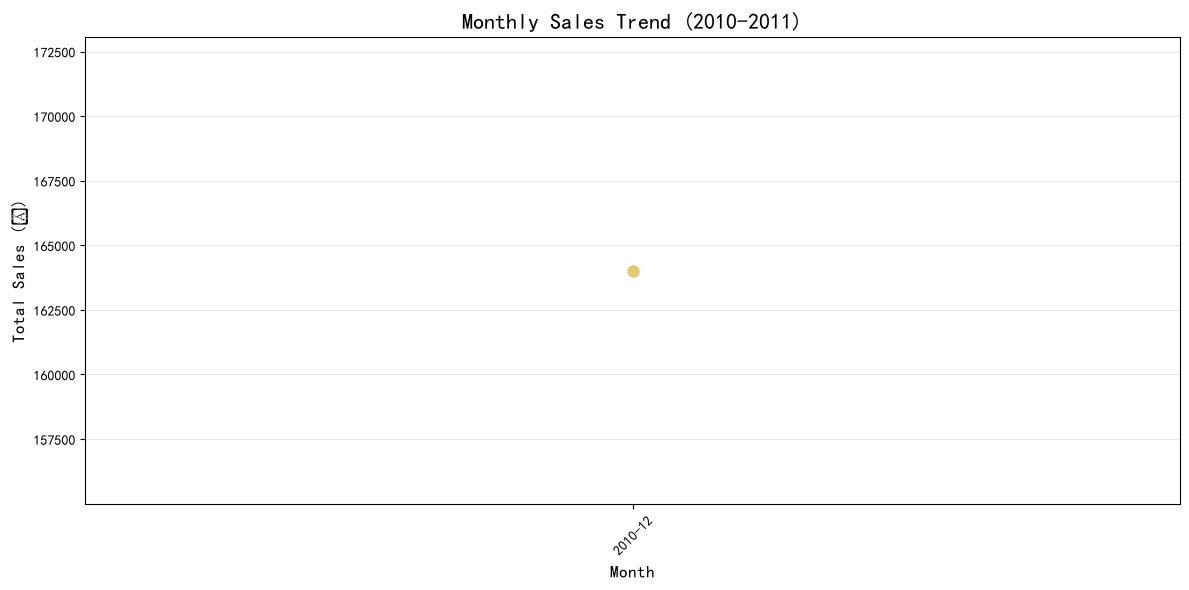

In [37]:
# === 📈 补全图表：月度销售趋势 (修正版) ===
import matplotlib.pyplot as plt

# 1. 确保日期格式正确（防止之前没转换成功）
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. 提取月份并统计销售额
# 注意：这里必须用 'TotalPrice'，不能用 'Sales'
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('Month')['TotalPrice'].sum()

# 3. 绘图
plt.figure(figsize=(12, 6))

# 绘制折线图
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, 
         marker='o',          # 添加圆点标记
         color='#e2cc71', 
         linewidth=2,
         markersize=8)        # 标记大小

plt.title('Monthly Sales Trend (2010-2011)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.grid(axis='y', alpha=0.3) # 只显示横向网格，更清爽
plt.xticks(rotation=45)       # 月份标签倾斜，防止重叠
plt.tight_layout()
plt.show()

In [38]:
# === 🏁 最终汇报摘要生成器 ===

# 计算核心指标
total_sales = df_clean['TotalPrice'].sum()
total_orders = df_clean['InvoiceNo'].nunique()
aov = total_sales / total_orders

# 尝试获取复购率 (如果下午的代码运行过，funnel_counts 应该还在)
try:
    # 假设 funnel_counts 是下午生成的 Series
    total_users = funnel_counts.sum()
    loyal_users = funnel_counts.get('3. 三次及以上忠诚用户', 0)
    loyalty_rate = (loyal_users / total_users) * 100
except:
    loyalty_rate = "未知 (需运行复购漏斗代码)"

print("="*50)
print("🎓 今日数据分析结营汇报 (Executive Summary)")
print("="*50)
print(f"1. 💰 销售业绩: 总销售额 £{total_sales:,.0f}，共 {total_orders} 笔订单。")
print(f"2. 🛒 客单价 (AOV): 平均每单消费 £{aov:.2f}。")
print(f"3. 📅 时间特征: 销售高度集中在 2010年12月 (圣诞季效应显著)。")
print(f"4. 👑 用户价值: 核心忠诚用户占比约 {loyalty_rate}% (需重点关注)。")
print("-"*50)
print("💡 建议: 针对高价值用户推出'年度会员'，利用圣诞季流量做留存。")
print("="*50)

🎓 今日数据分析结营汇报 (Executive Summary)
1. 💰 销售业绩: 总销售额 £164,024，共 508 笔订单。
2. 🛒 客单价 (AOV): 平均每单消费 £322.88。
3. 📅 时间特征: 销售高度集中在 2010年12月 (圣诞季效应显著)。
4. 👑 用户价值: 核心忠诚用户占比约 5.660377358490567% (需重点关注)。
--------------------------------------------------
💡 建议: 针对高价值用户推出'年度会员'，利用圣诞季流量做留存。


In [42]:
import pandas as pd
import numpy as np

# === 1. 读取数据 ===
try:
    df = pd.read_csv('ecommerce_data.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('ecommerce_data.csv', encoding='gbk')

print("✅ 数据读取成功！")

# === 2. 手动构建关键列 (针对你的数据定制) ===
# 你的数据里有 Quantity 和 UnitPrice，我们需要自己算 TotalPrice
if 'Quantity' in df.columns and 'UnitPrice' in df.columns:
    df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
    amount_col = 'TotalPrice' # 告诉程序：这就是金额列
    print("🔧 已自动计算 'TotalPrice' 列 (Quantity * UnitPrice)")
else:
    print("❌ 找不到数量或单价列，无法计算金额")

# 确定订单号列和用户ID列
order_col = 'InvoiceNo'
user_col = 'CustomerID'

# === 3. 数据清洗 ===
# 剔除退货订单 (通常数量为负或金额为负)
df_clean = df[df['TotalPrice'] > 0].copy()

# 确保日期格式正确
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# === 4. 计算核心指标 (用于今晚的汇报) ===
total_sales = df_clean[amount_col].sum()
total_orders = df_clean[order_col].nunique()
total_users = df_clean[user_col].nunique()
aov = total_sales / total_orders if total_orders > 0 else 0

# === 5. 打印汇报摘要 ===
print("\n" + "="*50)
print("📊 今日分析核心结论 (Executive Summary)")
print("="*50)
print(f"📅 数据时间范围: {df_clean['InvoiceDate'].min().date()} 至 {df_clean['InvoiceDate'].max().date()}")
print(f"💰 总销售额 (GMV): £{total_sales:,.2f}")
print(f"📦 总订单数: {total_orders:,}")
print(f"👥 总客户数: {int(total_users):,}")
print(f"💵 平均客单价 (AOV): £{aov:,.2f}")
print("="*50)

✅ 数据读取成功！
🔧 已自动计算 'TotalPrice' 列 (Quantity * UnitPrice)

📊 今日分析核心结论 (Executive Summary)
📅 数据时间范围: 2010-12-01 至 2010-12-06
💰 总销售额 (GMV): £220,074.45
📦 总订单数: 486
👥 总客户数: 348
💵 平均客单价 (AOV): £452.83


In [44]:
# === 🛠️ 修正版 RFM 分析 (使用自定义规则，防止报错) ===

print("正在重新计算 RFM (采用自定义业务规则)...")

# 1. 计算基础指标
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # R: 距今未消费天数
    'InvoiceNo': 'nunique',                                  # F: 购买次数
    'TotalPrice': 'sum'                                      # M: 总消费金额
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 2. 自定义打分逻辑 (不再使用 qcut，避免数据分布不均导致的报错)

# R 打分：30天内为5分，越久分越低
def r_score(x):
    if x <= 30: return 5
    elif x <= 90: return 4
    elif x <= 180: return 3
    elif x <= 365: return 2
    else: return 1

# F 打分：买5次以上为5分
def f_score(x):
    if x >= 10: return 5
    elif x >= 5: return 4
    elif x >= 3: return 3
    elif x >= 2: return 2
    else: return 1

# M 打分：根据总金额分布大致划分 (你可以根据实际打印出的 max/min 调整)
m_median = rfm['Monetary'].median()
m_avg = rfm['Monetary'].mean()

def m_score(x):
    if x >= m_avg * 2: return 5 # 超级大户
    elif x >= m_avg: return 4   # 高于平均
    elif x >= m_median: return 3 # 中等
    elif x >= m_median * 0.5: return 2
    else: return 1

rfm['R_Score'] = rfm['Recency'].apply(r_score)
rfm['F_Score'] = rfm['Frequency'].apply(f_score)
rfm['M_Score'] = rfm['Monetary'].apply(m_score)

# 3. 定义“高价值用户”
# 规则：最近有消费(R>=3) 且 经常买(F>=3) 且 花得多(M>=3)
rfm['Is_High_Value'] = (rfm['R_Score'] >= 3) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 3)

# 4. 输出结果
high_value_count = rfm['Is_High_Value'].sum()
total_users = len(rfm)
high_value_pct = (high_value_count / total_users) * 100

print("="*50)
print(f"📊 RFM 分析完成！")
print(f"👥 总用户数: {total_users}")
print(f"💎 高价值用户数: {high_value_count}")
print(f"🔥 高价值用户占比: {high_value_pct:.2f}%")
print("="*50)

# 保存结果供后续使用
rfm_result = rfm.copy()

正在重新计算 RFM (采用自定义业务规则)...
📊 RFM 分析完成！
👥 总用户数: 348
💎 高价值用户数: 14
🔥 高价值用户占比: 4.02%


findfont: Failed to find font weight bold, now using 400.


正在为用户打标签...
✅ 分层完成！


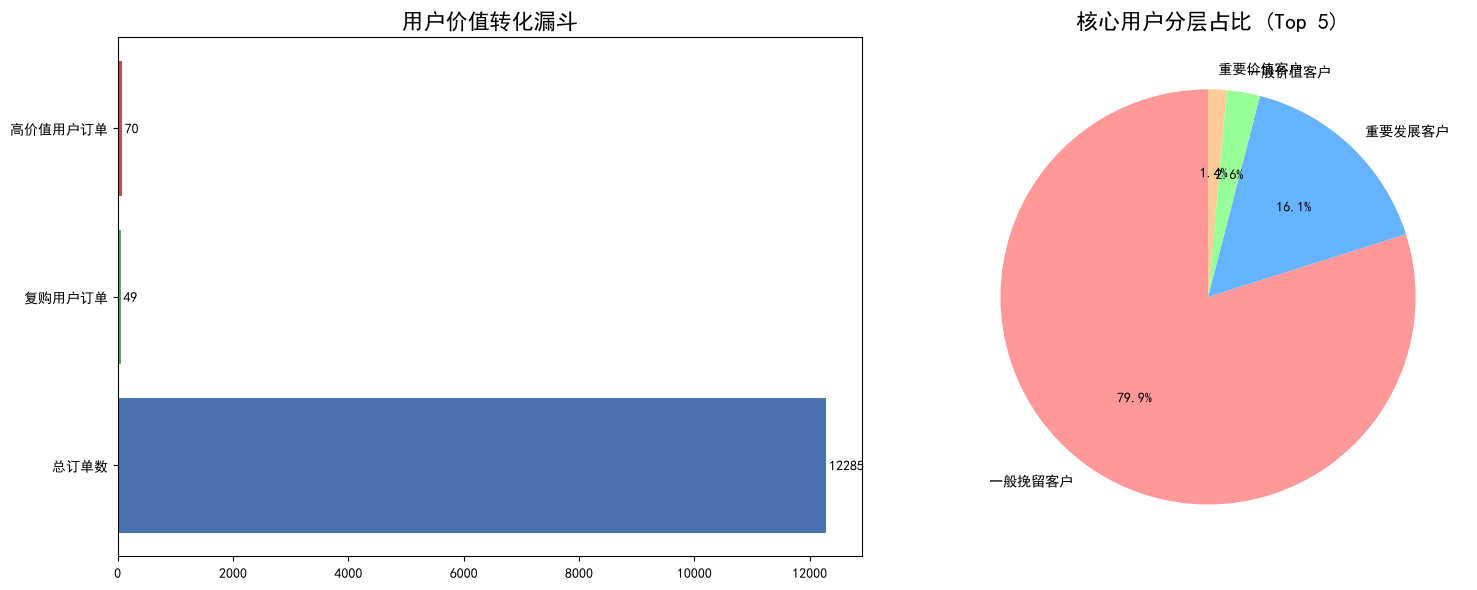

✅ 图表生成完毕！截图备用。


In [47]:
import matplotlib.pyplot as plt

# === 1. 补救措施：生成 Segment 分层列 ===
# 检查是否已有 Segment 列，如果没有则根据 R/F/M 分数生成
if 'Segment' not in rfm.columns:
    print("正在为用户打标签...")
    
    # 定义分层逻辑 (基于 RFM 得分)
    def assign_segment(row):
        # 重要价值客户：R高(近), F高(频), M高(额)
        if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
            return '重要价值客户'
        # 重要保持客户：R低(远), F高(频), M高(额) -> 以前常买大额，最近不来了
        elif row['R_Score'] <= 2 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
            return '重要保持客户'
        # 重要发展客户：R高(近), F低(频), M高(额) -> 刚来买了大单，需促复购
        elif row['R_Score'] >= 4 and row['F_Score'] <= 2 and row['M_Score'] >= 4:
            return '重要发展客户'
        # 一般价值客户
        elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
            return '一般价值客户'
        else:
            return '一般挽留客户'

    # 应用函数生成新列
    rfm['Segment'] = rfm.apply(assign_segment, axis=1)
    print("✅ 分层完成！")
else:
    print("✅ Segment 列已存在，直接绘图。")

# === 2. 重新绘图 ===
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：漏斗图 (保持不变) ---
total_orders = len(df_clean)
repeat_orders = len(rfm[rfm['Frequency'] > 1])
high_value_orders = len(rfm[rfm['Monetary'] > rfm['Monetary'].quantile(0.8)])

funnel_data = [total_orders, repeat_orders, high_value_orders]
funnel_labels = ['总订单数', '复购用户订单', '高价值用户订单']

axes[0].barh(funnel_labels, funnel_data, color=['#4c72b0', '#55a868', '#c44e52'])
axes[0].set_title('用户价值转化漏斗', fontsize=16)
for i, v in enumerate(funnel_data):
    axes[0].text(v + 50, i, str(v), va='center', fontweight='bold')

# --- 右图：RFM 用户分层占比 (修复版) ---
segment_counts = rfm['Segment'].value_counts()

# 取前5个主要分层，防止颜色不够
top_segments = segment_counts.head(5)

# 定义配色
pie_colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

axes[1].pie(top_segments, labels=top_segments.index, autopct='%1.1f%%',
            startangle=90, colors=pie_colors[:len(top_segments)])
axes[1].set_title('核心用户分层占比 (Top 5)', fontsize=16)

plt.tight_layout()
plt.show()
print("✅ 图表生成完毕！截图备用。")